First 5 Rows
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0      

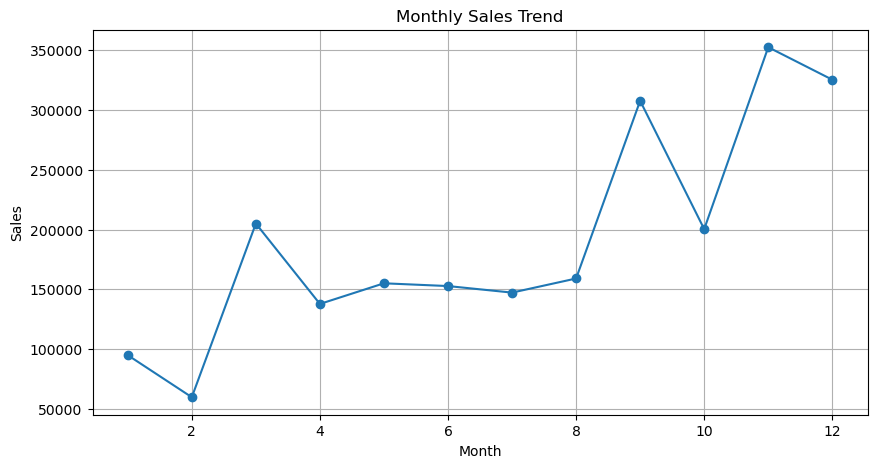


Predicted Sales
[223.48685132 230.54206962 229.3661999  230.54206962 222.31098161
 229.3661999  229.3661999  223.48685132 222.31098161 223.48685132]

Mean Absolute Error
285.5118568039595

R2 Score
-0.0010068332158201798


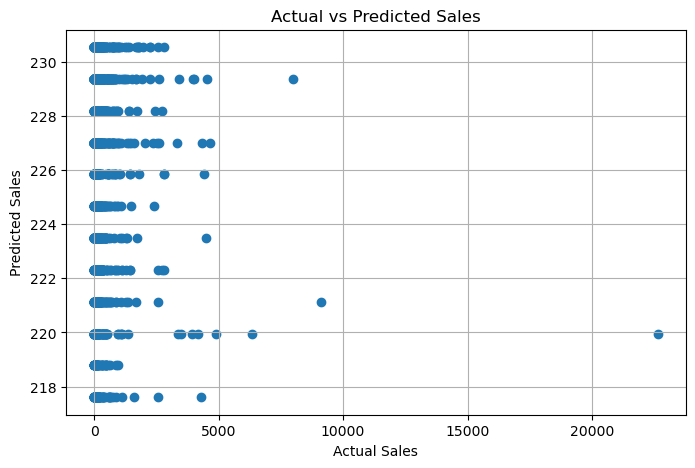

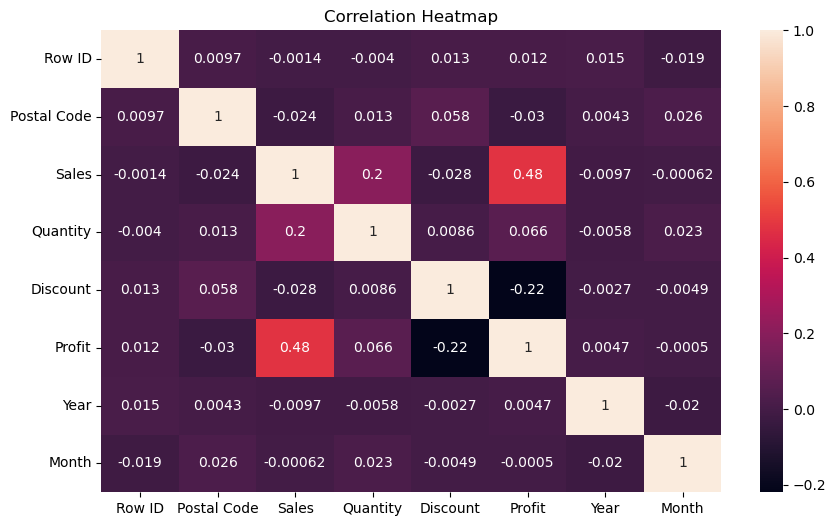


Future Sales Predictions
Month: 1 Predicted Sales: 217.60750274437726
Month: 2 Predicted Sales: 218.7833724602928
Month: 3 Predicted Sales: 219.95924217620833
Month: 4 Predicted Sales: 221.13511189212386
Month: 5 Predicted Sales: 222.31098160803938
Month: 6 Predicted Sales: 223.4868513239549

Prediction output file saved successfully

Predictive Analytics Project Completed Successfully


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Load Dataset
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

print("First 5 Rows")
print(df.head())

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

monthly_sales = df.groupby('Month')['Sales'].sum()

print("\nMonthly Sales")
print(monthly_sales)

plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

X = df[['Month']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("\nPredicted Sales")
print(predictions[:10])

mae = mean_absolute_error(y_test, predictions)

print("\nMean Absolute Error")
print(mae)

r2 = r2_score(y_test, predictions)

print("\nR2 Score")
print(r2)

plt.figure(figsize=(8,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.grid(True)

plt.show()

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(numeric_df.corr(), annot=True)

plt.title("Correlation Heatmap")

plt.show()

future_months = pd.DataFrame({
    'Month': [1, 2, 3, 4, 5, 6]
})

future_predictions = model.predict(future_months)

print("\nFuture Sales Predictions")

for month, sales in zip(future_months['Month'], future_predictions):
    print("Month:", month, "Predicted Sales:", sales)

output = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': predictions
})

output.to_csv("Predicted_Sales_Output.csv", index=False)

print("\nPrediction output file saved successfully")

print("\nPredictive Analytics Project Completed Successfully")